# Introduction to Feature Engineering

In many machine learning tasks, the **quality of the features** often matters more than the complexity of the model. Feature engineering refers to the process of **transforming raw data into meaningful input variables (features)** that improve the performance of machine learning models.

Raw data collected from real-world systems is often:

- messy  
- incomplete  
- poorly formatted  
- not directly useful for modeling  

Feature engineering helps convert raw data into **structured, informative inputs** that models can learn from.

A simple model with well-engineered features can often perform **better than a complex model trained on poorly prepared data**.



## What is a Feature?

A **feature** is an individual measurable property **used as input** to a machine learning model. In a dataset:

- **Rows** represent observations
- **Columns** represent features

Example dataset:

| Student_ID | Study_Hours | Attendance | Final_Grade |
|------------|-------------|------------|-------------|
| 1 | 5 | 90 | 85 |
| 2 | 2 | 60 | 65 |
| 3 | 8 | 95 | 92 |

Here:

- `Study_Hours` → feature  
- `Attendance` → feature  
- `Final_Grade` → target variable  


## Why Feature Engineering Matters

Feature engineering helps models:

- capture meaningful patterns
- reduce noise
- improve prediction accuracy
- generalize better to unseen data

**Example:**

- Raw feature: Date = 2026-03-11

- Engineered features:

  - Day_of_week = Wednesday  
  - Month = March  
  - Is_weekend = False  

These engineered features may better capture behavioral patterns.



## Feature Engineering in the Data Science Pipeline

Feature engineering occurs **after data cleaning but before model training**. Typical workflow:


| Raw Data | → | Data Cleaning | → | Feature Engineering | → | Model Training | → | Model Evaluation |
|----------|---|---------------|---|---------------------|---|---------------|---|-----------------|

<p align="center">
<img src="https://media.geeksforgeeks.org/wp-content/uploads/20250701114435618562/feature-engineering.webp" width="600">
</p>


<em>Figure: Overview of the Feature Engineering Process. Source: GeeksforGeeks
</p>

Feature engineering is often **iterative**, meaning data scientists repeatedly refine features to improve model performance.


# Types of Feature Engineering

Feature engineering generally involves **three** major types of operations:

- **Feature Creation**
- **Feature Transformation**
- **Feature Selection**

Each type plays a different role in improving the quality of input data for machine learning models.



## 1. Feature Creation

Feature creation involves **generating new variables from existing data**.  These new variables may capture relationships that the original features do not directly represent.

Examples:

| Original Features | Engineered Feature |
|------------------|-------------------|
| height, weight | BMI = weight / height² |
| purchase_count, visits | average_purchase_value |
| date | day_of_week, month, is_weekend |



### Example: Housing Dataset

Original features:

| Size_sqft | Bedrooms | Price |
|----------|----------|------|
| 1500 | 3 | 450000 |

Engineered features:

- price_per_sqft
- bedrooms_per_sqft
- house_age

These engineered features may better capture housing patterns.


In [1]:
import pandas as pd

df = pd.DataFrame({
    "size_sqft":[1500,1800,1200],
    "price":[450000,520000,350000]
})

df["price_per_sqft"] = df["price"] / df["size_sqft"]

df

,size_sqft,price,price_per_sqft
0,1500,450000,300.000000
1,1800,520000,288.888889
2,1200,350000,291.666667


Remember, Feature creation often uses domain knowledge to design useful variables.

## Types of Feature Creation:
Common creation techniques include:

- Polynomial Features
- Interaction Features
### 1a. Polynomial Features

Polynomial features are created by **raising existing features to a power**.  They allow models to capture **nonlinear relationships** between variables.

For example, suppose we are predicting house prices using the size of a house.

| Size (sqft) | Price |
|-------------|-------|
| 1000 | 200000 |
| 1500 | 300000 |
| 2000 | 450000 |

The relationship between size and price may **not be perfectly linear**. To capture nonlinear patterns, we can create polynomial features:

$$
x^2, x^3, ...
$$

### Example:

| Size | Size² |
|-----|------|
| 1000 | 1,000,000 |
| 1500 | 2,250,000 |

These new variables allow models to learn **curved relationships**.


### Example Python Code

```python
from sklearn.preprocessing import PolynomialFeatures
import pandas as pd

df = pd.DataFrame({
    "size":[1000,1500,2000]
})

poly = PolynomialFeatures(degree=2, include_bias=False)

poly_features = poly.fit_transform(df)

pd.DataFrame(poly_features, columns=["size","size_squared"])
```

Polynomial features are commonly used with models such as:

- Linear Regression
- Logistic Regression

They allow simple models to capture complex patterns.

### 1b. Interaction Features

Interaction features are created by **multiplying two or more features together**. They capture relationships where the **combined effect of multiple variables matters**.

### Example

Suppose we want to predict **house prices** using:

- house size
- neighborhood quality score

| Size | Neighborhood Score |
|------|--------------------|
| 1500 | 8 |
| 1500 | 4 |

Two houses may have the **same size**, but if one is in a better neighborhood, the price may be higher. An interaction feature can capture this relationship.

$$
Interaction = Size \times NeighborhoodScore
$$

### Example Table

| Size | Neighborhood | Size × Neighborhood |
|------|--------------|---------------------|
| 1500 | 8 | 12000 |
| 1500 | 4 | 6000 |

This feature helps the model understand that **price depends on both variables together**.



### Example Python Code

```python
df["size_neighborhood_interaction"] = df["size"] * df["neighborhood_score"]
```

### Why These Features Matter?

Polynomial and interaction features help models capture complex relationships in data.

- Polynomial Features	Capture nonlinear patterns
- Interaction Features	Capture relationships between multiple variables

These techniques are widely used in:
- regression models
- recommendation systems
- predictive analytics

## 2. Feature Transformation

Feature transformation refers to modifying existing features to improve their **scale, distribution, or representation** so that machine learning models can learn patterns more effectively.

Common transformation techniques include:

- Scaling and Normalization  
- Standardization  
- Log Transformation  
- Encoding Categorical Variables  
- Discretization (Binning)  
- Text Feature Extraction (**Later Chapter**)


### 2a. Scaling and Normalization

Scaling adjusts the **range of numerical values** so that features are comparable.

Example:

| Feature | Range |
|------|------|
| Age | 18 – 60 |
| Income | 20,000 – 200,000 |

Because income has a much larger range, some models may give it **more influence**.

### Min-Max Normalization

This method rescales values to the **0–1 range**.

$$
x' = \frac{x - min(x)}{max(x) - min(x)}
$$

Example python code:

```python
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df[["income"]])
```
### Standardization

Standardization transforms values so that they have mean = 0 and standard deviation = 1

Formula:

$$
z = \frac{x - 𝜇}{σ}
$$


Where:
- μ = mean
- σ = standard deviation

Example python code:

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_standardized = scaler.fit_transform(df[["income"]])
```
Standardization is commonly used in algorithms such as:

- Logistic Regression
- Support Vector Machines
- K-Means Clustering


### 2b. Log Transformation

Log transformation is used when data is **highly skewed** or contains **very large values**.  
It helps reduce the influence of extreme values and makes the distribution more balanced.

#### Example Data

| Income |
|------|
| 30000 |
| 40000 |
| 50000 |
| 900000 |

Applying a log transformation compresses large values.

$$
x' = \log(x)
$$

This transformation is commonly used for variables such as:

- income
- population
- sales
- transaction amounts


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Example dataset
df = pd.DataFrame({
    "income": [30000, 40000, 50000, 900000]
})

# Apply log transformation
df["log_income"] = np.log(df["income"])

df


,income,log_income
0,30000,10.308953
1,40000,10.596635
2,50000,10.819778
3,900000,13.710150


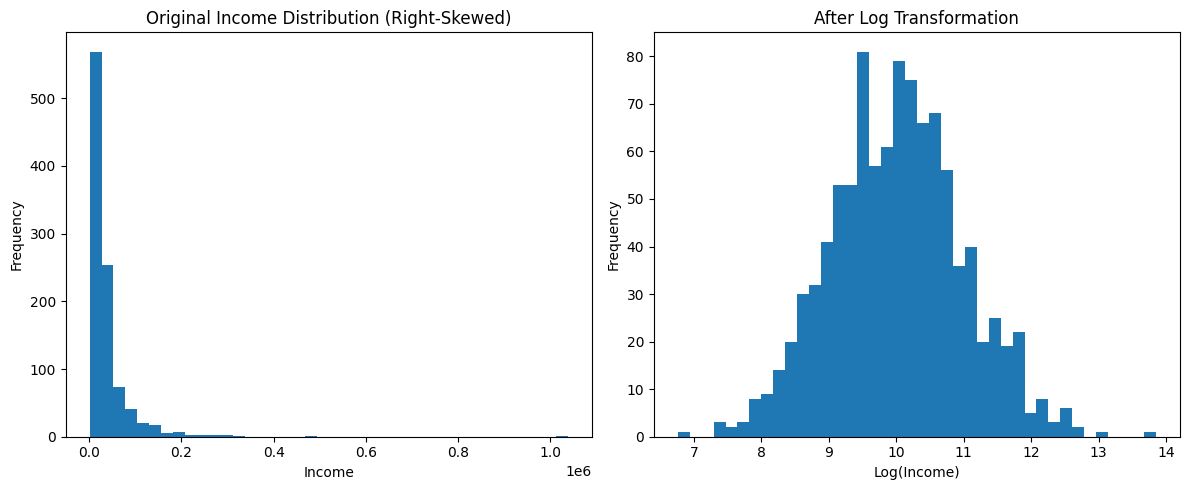

In [7]:
# another example
import numpy as np
import matplotlib.pyplot as plt

# Generate skewed income data
np.random.seed(42)
income = np.random.lognormal(mean=10, sigma=1, size=1000)

# Log transform
log_income = np.log(income)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(income, bins=40)
plt.title("Original Income Distribution (Right-Skewed)")
plt.xlabel("Income")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
plt.hist(log_income, bins=40)
plt.title("After Log Transformation")
plt.xlabel("Log(Income)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

Remember, Log transformation is especially useful when a feature has a right-skewed distribution, meaning a small number of observations have extremely large values.

### 2c. Feature Encoding (Categorical Variables)

Machine learning models require **numerical input**, so categorical variables must be converted into numbers before they can be used in most algorithms. Example categorical feature:

| Color |
|------|
| Red |
| Blue |
| Green |

Several encoding techniques can be used depending on the **type of categorical data** and the **number of categories**.


### (I) One-Hot Encoding

One-hot encoding creates a **binary column for each category**.

| Color | Red | Blue | Green |
|------|----|----|----|
| Red | 1 | 0 | 0 |
| Blue | 0 | 1 | 0 |

<p align="center">
<img src="https://miro.medium.com/v2/1*ggtP4a5YaRx6l09KQaYOnw.png" width="600">
<em>Figure: One-Hot Encoding. Source: Medium
</p>


**Suitable for:** Nominal data (categories with no natural order)

Example code:

```python
pd.get_dummies(df["color"])
```

### (II) Label Encoding

Each category is assigned a **numeric label**.

| Category | Encoded Value |
|---------|---------------|
| Low | 1 |
| Medium | 2 |
| High | 3 |


<p align="center">
<img src="https://substackcdn.com/image/fetch/$s_!GeUu!,f_auto,q_auto:good,fl_progressive:steep/https%3A%2F%2Fsubstack-post-media.s3.amazonaws.com%2Fpublic%2Fimages%2F86a58fb1-a019-48af-ac6f-9b91e8191da3_1664x988.png" width="400">
</p>
<p align="center"><em>Figure: Label Encoding. Source: Daily Dose of Data Science</p>


**Suitable for:** Ordinal data (categories with natural order)

Example code:

```python
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df["category_encoded"] = encoder.fit_transform(df["category"])
```

> Note: Label encoding may introduce **artificial ordering** when categories do not have a natural order.


### (III) Frequency Encoding

Frequency encoding replaces categories with the **frequency of their occurrence in the dataset**.

Example:

| Category | Frequency |
|----------|-----------|
| A | 0.40 |
| B | 0.35 |
| C | 0.25 |

**Suitable for:** High-cardinality categorical variables.

> **High-cardinality categorical variables** are categorical features that contain a **large number of unique categories** (for example, hundreds or thousands of values such as city names, product IDs, or user IDs).

Example:

| City |
|------|
| New York |
| Chicago |
| Los Angeles |
| Houston |
| Phoenix |
| ... |

If a feature contains many unique categories, using **One-Hot Encoding** would create a large number of new columns. In such cases, **frequency encoding** is often a more efficient approach.

Example Python Code:

```python
freq = df["category"].value_counts(normalize=True)
df["category_freq"] = df["category"].map(freq)
```

### (IV) Target (Mean) Encoding

Target encoding replaces each category with the **average value of the target variable for that category**.

Example:

| City | Average House Price |
|------|---------------------|
| City A | 350000 |
| City B | 420000 |

In this approach, each category is replaced by the **mean value of the target variable** for that category.

For example, if houses in **City A** have an average price of **350,000**, then all instances of **City A** may be encoded as **350000**.

**Suitable for:** Categorical variables with **many categories** where the category has a relationship with the target variable.

**Warning:** Target encoding must be applied carefully to **avoid data leakage**, especially when the target values from the test data influence the encoding.

-----------
-----------
### **BONUS:** What is Data Leakage?

Data leakage occurs when a model accidentally uses **information that would not be available at prediction time**. This can cause the model to appear **very accurate during training**, but perform poorly on new data.

### Example of Leakage with Target Encoding

Suppose we want to predict **house prices** using the city as a feature.

| City | Price |
|------|------|
| A | 300000 |
| A | 400000 |
| B | 420000 |

If we compute the **average price using the entire dataset**, including the test data, the model indirectly gains information about the values it is supposed to predict. This creates **data leakage**.

### Correct Approach

To avoid leakage:

1. Split the dataset into **training and test sets first**.
2. Compute the **target encoding using only the training data**.
3. Apply the learned encoding to the test data.

-----------
-----------

### Example Python Code

```python
import pandas as pd

# Example dataset
df = pd.DataFrame({
    "city": ["A", "A", "B", "B", "B"],
    "price": [300000, 400000, 420000, 410000, 430000]
})

# Compute mean target value for each category
target_mean = df.groupby("city")["price"].mean()

# Map the mean values back to the dataset
df["city_target_encoded"] = df["city"].map(target_mean)

df
```

Note: In practice, target encoding should be computed **using training data only**


### (V) Probability Encoding

Probability encoding replaces categories with the **conditional probability of the target variable given the category**.

Example:

| Category | P(Target = 1 \| Category) |
|----------|---------------------------|
| A | 0.70 |
| B | 0.45 |

In this case, category **A** has a 70% probability of belonging to the target class, while category **B** has a 45% probability.

This approach is useful in **classification problems** where categories have different probabilities of belonging to the target class.


### 2d. Discretization (Binning)

Discretization, also called **binning**, is the process of converting **continuous numerical variables into categorical groups (bins)**. Instead of using the exact numeric value, the variable is grouped into ranges.

This can help:

- simplify patterns in the data  
- reduce noise  
- improve interpretability  
- make some models easier to train  

### Example

| Age | Age_Group |
|-----|-----------|
| 22 | Young |
| 35 | Adult |
| 65 | Senior |

Instead of using exact ages, we categorize them into meaningful groups.

---

### Example Code

```python
import pandas as pd

df = pd.DataFrame({
    "age":[22,35,65,18,45]
})

df["age_group"] = pd.cut(df["age"], bins=[0,18,35,60,100])

df
```
## Types of Binning:

- **Equal Width Binning**:  Each bin has the same numerical range. Example:
  - 0–20
  - 20–40
  - 40–60
  - 60–80
- **Equal Frequency Binning**: Each bin contains approximately the same number of observations.

Example Python code:
```python
df["age_bin"] = pd.qcut(df["age"], q=3)
```
Binning is helpful when:

- the exact numeric value is not necessary
- the variable has high variability
- interpretability is important

Example:
- Age → Age group
- Income → Income bracket
- Temperature → Cold / Moderate / Hot

## 3. Feature Selection

Feature selection is the process of **choosing the most relevant features for a machine learning model and removing irrelevant or redundant variables**.

Reducing unnecessary features can help:

- improve model performance  
- reduce overfitting  
- decrease training time  
- make models easier to interpret  

### Example

Original features:

| Size | Bedrooms | Zip Code | Price |
|------|----------|----------|------|

If **Zip Code** does not contribute to predicting house price, it may be removed.

Selected features:

| Size | Bedrooms | Price |

### Common Approaches

| Method | Description |
|------|-------------|
| Filter Methods | Use statistical measures such as correlation to select features |
| Wrapper Methods | Evaluate different feature combinations using a model |
| Embedded Methods | Feature selection occurs during model training (e.g., Lasso, decision trees) |

# Summary of the Chapter

Feature engineering is the process of transforming raw data into meaningful inputs that improve the performance of machine learning models.

In this chapter, we introduced several important feature engineering techniques:

- **Feature Creation:** Generating new features from existing variables (e.g., polynomial features, interaction features).
- **Feature Transformation:** Modifying features to improve scale, distribution, or representation (e.g., scaling, log transformation, encoding).
  - **Encoding Categorical Variables:** Converting categorical data into numerical form using methods such as one-hot encoding, label encoding, frequency encoding, and target encoding.
  - **Discretization (Binning):** Converting continuous numerical variables into categorical groups.
- **Feature Selection:** Identifying and keeping the most informative features while removing irrelevant or redundant ones.

Effective feature engineering can significantly improve model performance and interpretability. In practice, it is often an **iterative process**, where features are refined and evaluated repeatedly during model development.


# Knowledge Check